<div align="center">

# Measuring Snow Depth with ICESat-2

$$
\Large \text{The pathlength method} \\
$$

$$
\Large \text{Tutorials for working with NASA ICESat-2 ATL03 datasets for snow depth study} \\
$$



$$
\text{Xiaomei Lu } \\
$$

$$
\text{xiaomei.lu@nasa.gov} \\
$$

$$
\text{NASA Langley Research Center, Hampton, VA}
$$

$$
\text{April 29, 2026}
$$

</div>

## Function used to read ATL03 data

In [47]:
import numpy as np
import h5py
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pandas as pd

def read_icesat2_atl03_gt3l(fn, surface_flag):
    """
    Simplified ICESat-2 ATL03 reader for GT3L only.

    Parameters
    ----------
    fn : str
        Path to ATL03 HDF5 file
    surface_flag : int
        Column index in signal_conf_ph used to filter surface type

    Returns
    -------
    h_3r : ndarray or None
        Processed photon data for GT3L
    """

    with h5py.File(fn, "r") as f:

        beam = "gt3l"

        # ----------------------------
        # Check if beam exists
        # ----------------------------
        if f"/{beam}" not in f:
            return None

        # ----------------------------
        # Signal confidence filtering
        # ----------------------------
        sig_conf = f[f"/{beam}/heights/signal_conf_ph"][()]
        # sig_conf = np.array(f[f'gt3{LR}/heights/signal_conf_ph'])
        ind_ocean = np.where(
            (sig_conf[:, surface_flag] != -1) &
            (sig_conf[:, surface_flag] != -2)
        )[0]

        if len(ind_ocean) == 0:
            return None

        # ----------------------------
        # Core photon data
        # ----------------------------
        lat = f[f"/{beam}/heights/lat_ph"][()]
        lon = f[f"/{beam}/heights/lon_ph"][()]
        time = f[f"/{beam}/heights/delta_time"][()]
        h_ph = f[f"/{beam}/heights/h_ph"][()]

        h_3r = np.column_stack((lat, lon, time, h_ph))

        # ----------------------------
        # Background rate
        # ----------------------------
        bt = f[f"/{beam}/bckgrd_atlas/delta_time"][()]
        br = f[f"/{beam}/bckgrd_atlas/bckgrd_rate"][()]

        f_bck = interp1d(bt, br, bounds_error=False, fill_value=np.nan)
        bckgrd = f_bck(time)

        # ----------------------------
        # DEM + Geoid
        # ----------------------------
        dem_t = f[f"/{beam}/geophys_corr/delta_time"][()]
        dem_h = f[f"/{beam}/geophys_corr/dem_h"][()]
        geoid = f[f"/{beam}/geophys_corr/geoid"][()]

        dem_h = np.where(dem_h > 1e10, np.nan, dem_h)
        geoid = np.where(geoid > 1e10, np.nan, geoid)

        f_dem = interp1d(dem_t, dem_h, bounds_error=False, fill_value=np.nan)
        f_geo = interp1d(dem_t, geoid, bounds_error=False, fill_value=np.nan)

        demh = f_dem(time)
        geoid_1 = f_geo(time)

        # ----------------------------
        # Solar elevation
        # ----------------------------
        sol_t = f[f"/{beam}/geolocation/delta_time"][()]
        sol = f[f"/{beam}/geolocation/solar_elevation"][()]

        sol = np.where(sol > 360, np.nan, sol)

        f_sol = interp1d(sol_t, sol, bounds_error=False, fill_value=np.nan)
        solarele = f_sol(time)

        # ----------------------------
        # Along-track distance (simplified)
        # ----------------------------
        dist = f[f"/{beam}/heights/dist_ph_along"][()]
        seglen = f[f"/{beam}/geolocation/segment_length"][()]

        total_dist = np.sum(seglen) + dist[-1]
        dist_km = np.linspace(0, total_dist, len(dist)) / 1000.0

        # ----------------------------
        # Filter valid photons
        # ----------------------------
        h_3r = h_3r[ind_ocean, :]
        h_3r = np.column_stack((
            h_3r,
            sig_conf[ind_ocean, :],
            geoid_1[ind_ocean],
            bckgrd[ind_ocean],
            demh[ind_ocean],
            solarele[ind_ocean],
            dist_km[ind_ocean]
        ))

        # Optional: weight_ph
        if f"{beam}/heights/weight_ph" in f:
            weight = f[f"/{beam}/heights/weight_ph"][()]
            h_3r = np.column_stack((h_3r, weight[ind_ocean]))

        return h_3r

## Function for 2D histogram to bin ATL03 Photons

In [41]:
def hist_wt_sum(x, y, binx, biny):
    """
    2D histogram with sum and mean of y per (x,y) bin.
    Clean + NaN-safe version (no warnings).
    """

    x = np.asarray(x)
    y = np.asarray(y)

    lx = len(binx) - 1
    ly = len(biny) - 1

    dx = (binx[-1] - binx[0]) / lx
    dy = (biny[-1] - biny[0]) / ly

    nocc = np.zeros((lx + 1, ly + 1), dtype=float)
    occ = np.zeros((lx + 1, ly + 1), dtype=float)

    # -----------------------------
    # Compute bin indices
    # -----------------------------
    ix = np.round((x - binx[0]) / dx)
    iy = np.round((y - biny[0]) / dy)

    # -----------------------------
    # Keep only valid values
    # -----------------------------
    valid = (
        np.isfinite(ix) &
        np.isfinite(iy) &
        np.isfinite(x) &
        np.isfinite(y) &
        (ix >= 0) & (ix <= lx) &
        (iy >= 0) & (iy <= ly)
    )

    ix = ix[valid].astype(int)
    iy = iy[valid].astype(int)
    y = y[valid]

    # -----------------------------
    # Accumulate histogram
    # -----------------------------
    np.add.at(nocc, (ix, iy), 1)
    np.add.at(occ, (ix, iy), y)

    # -----------------------------
    # Convert to mean
    # -----------------------------
    occ = np.divide(
        occ,
        nocc,
        out=np.zeros_like(occ),
        where=nocc > 0
    )

    return nocc, occ

## Step 1 read ATL03 Photon heights

In [42]:
# The path and ATL03 data name
fn = '/Users/xlu2/Documents/Snow_depth/SnowEx/ACP/2023/ATL03_20230302092442_10971805_006_02.h5'
surface_flag=0;# over land surface

# this told read only beam 3 left beam
h_1r=read_icesat2_atl03_gt3l(fn, surface_flag)

# Photon height - DEM
h_ph = h_1r[:, 3]-h_1r[:, 11]
h_t = h_1r[:, 2] - np.min(h_1r[:, 2])

# only select the photons near surface
# and snow surface
ind00 = np.where(
    (h_ph <= 70) &
    (h_ph >= -80) &
    (h_t > 7.5) &
    (h_t < 13)
)[0]
h_1r = h_1r[ind00, :]
h_t = h_t[ind00]
#

h_lat=h_1r[:, 0]
h_ph = h_1r[:, 3]-h_1r[:, 11]

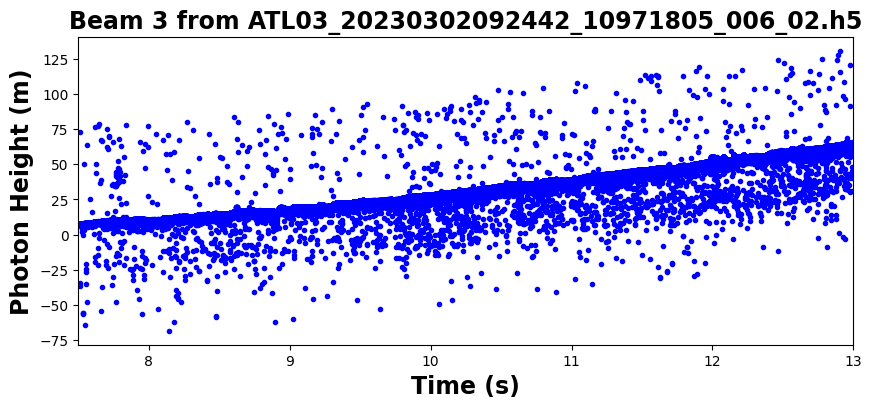

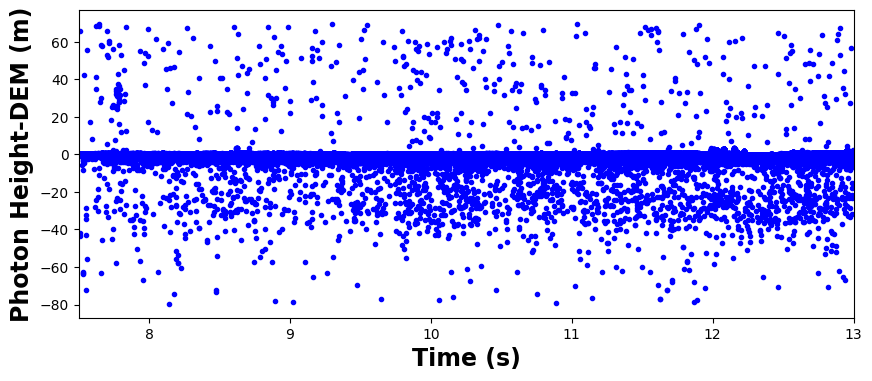

In [43]:
# plt.figure()
h_ph1 = h_1r[:, 3]

plt.figure(figsize=(10, 4))  

# plt.subplot(2, 1, 1)
# plt.plot(h_lat, h_ph, '.b')   # 
plt.plot(h_t, h_ph1, '.b')   # 
plt.xlim(7.5, 13)   # set x-axis range
# plt.ylim(-50, 20)  

plt.xlabel('Time (s)', fontsize=17, fontweight='bold')
plt.ylabel('Photon Height (m)', fontsize=17, fontweight='bold')
plt.title('Beam 3 from ATL03_20230302092442_10971805_006_02.h5', fontsize=17, fontweight='bold')

plt.figure(figsize=(10, 4))  
# plt.subplot(2, 1, 2)
plt.plot(h_t, h_ph, '.b')   # 
plt.xlim(7.5, 13)   # set x-axis range
# plt.ylim(-50, 20)  

plt.xlabel('Time (s)', fontsize=17, fontweight='bold')
plt.ylabel('Photon Height-DEM (m)', fontsize=17, fontweight='bold')



plt.show()

## Step 2 Generate Snow vertical profiles

### Define bin sizes in both the vertical (height) and along-track (time/distance) directions. For example, 15 cm in vertical by 7 m along track.

### Group photons into these bins and count how many photons fall within each bin.This process produces a 2D distribution (histogram) of photon counts, representing the vertical structure of photons along the satellite track.



In [44]:
# 15 cm in vertical bins
altbin1 = 15 / 100  # 1.5 cm → meters
# time along track
timebin1 = 0.001  # seconds ~ 7m along track distance

# set up vertical and along track bins
binx = np.arange(h_t[0], np.max(h_t), timebin1)
biny = np.arange(-60, 60 + altbin1, altbin1)

B_nocc, occ=hist_wt_sum(h_t,h_ph,binx,biny);

#for high confidence signal only
sig_conf=h_1r[:, 4]
ind33 = np.where(sig_conf == 4)[0]
B_nocc2, occ2 = hist_wt_sum(h_t[ind33], h_ph[ind33], binx, biny)

In [45]:
print(B_nocc.shape,binx.shape,biny.shape,h_t[0])

(5500, 802) (5500,) (802,) 7.500000178813934


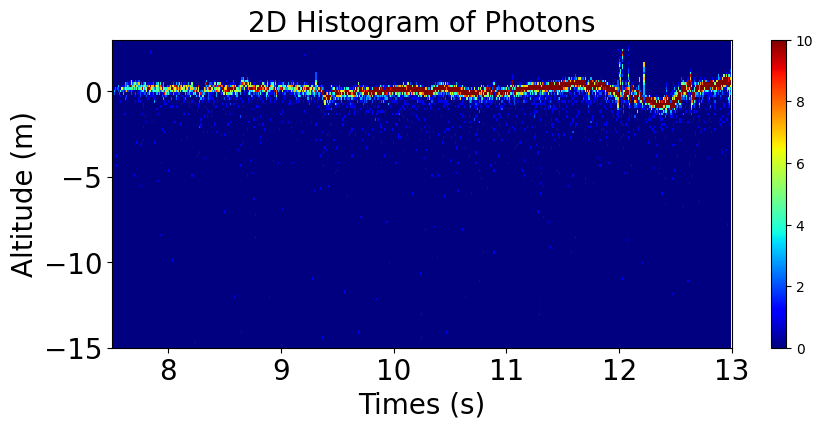

In [46]:
row1 = len(binx)
x = binx[:row1:10]
z = B_nocc[:row1:10, :].T   
X, Y = np.meshgrid(x, biny)

# plt.figure()
plt.figure(figsize=(10, 4))  
pcm = plt.pcolormesh(X, Y, z, cmap='jet', shading='auto')

plt.title('2D Histogram of Photons', fontsize=20)
plt.xlabel('Times (s)', fontsize=20)
plt.ylabel('Altitude (m)', fontsize=20)

plt.ylim([-15, 10])
plt.clim(0, 10)
plt.tick_params(labelsize=20)
plt.colorbar(pcm)
plt.ylim(-15, 3) 
plt.xlim(7.5, 13)   # set x-axis range
plt.show()

## Snow vertical profile retrieval relies on the relative height differences between photons, particularly the vertical distance between subsurface photons and surface photons.

### Set the snow surface to zero elevation, with depths below the surface represented as negative values. 


In [48]:
# set vertical profile range -6 to 30m
b_n = int(round(30 / altbin1))
u_n = int(round(6 / altbin1))

y_alt1 = np.arange(-b_n * altbin1,
                   u_n * altbin1 + altbin1,
                   altbin1)

# -----------------------------
# Initialize arrays (MATLAB-style NaN matrices)
# -----------------------------
b_2 = np.full((len(binx), len(y_alt1)), np.nan)
b_3 = np.full((len(binx), len(y_alt1)), np.nan)
total_ph = np.full((len(binx), 6), np.nan)

# -----------------------------
# Main loop
# -----------------------------
for i in range(len(binx)):

    sig = B_nocc[i, :]

    aa1 = np.max(sig)
    bb1 = np.argmax(sig)

    # safety check for bounds
    if (bb1 > b_n) and (aa1 > 0) and (bb1 + u_n < len(biny)):

        b_2[i, :] = sig[bb1 - b_n: bb1 + u_n + 1] / aa1
        b_3[i, :] = sig[bb1 - b_n: bb1 + u_n + 1]
    if aa1 > 0:

        col = B_nocc2[i, :]
        indvv = np.where(col > 0)[0]

        total_ph[i, 0] = np.sum(col)
        total_ph[i, 1] = aa1
        total_ph[i, 2] = np.max(col)

        if len(indvv) > 0:
            total_ph[i, 3] = np.std(col[indvv])
            total_ph[i, 4] = np.sum(col[indvv])
        else:
            total_ph[i, 3] = np.nan
            total_ph[i, 4] = np.nan

        total_ph[i, 5] = biny[bb1]

# -----------------------------
# Final filtering to remove no snow surface profiles (surface photon<1)
# -----------------------------
ind_v = np.where(
    (total_ph[:, 1] * 3 / 10 >= 0.3) &
    (total_ph[:, 0] * 3 / 10 >= 0.3)
)[0]

total_ph = total_ph[ind_v, :]
b_2 = b_2[ind_v, :]
b_3 = b_3[ind_v, :]
binx1=binx[ind_v]

# set along track averaging to increase SNR
ave_second = 0.015
depth_max = -15

averag_s = int(round(ave_second/timebin1))

b_2_mean = (
    pd.DataFrame(b_2)
    .rolling(window=averag_s, min_periods=1)
    .mean()
    .to_numpy()
)


In [49]:
print(binx1.shape, b_2.shape, b_2_mean.shape,averag_s)

(5498,) (5498, 241) (5498, 241) 15


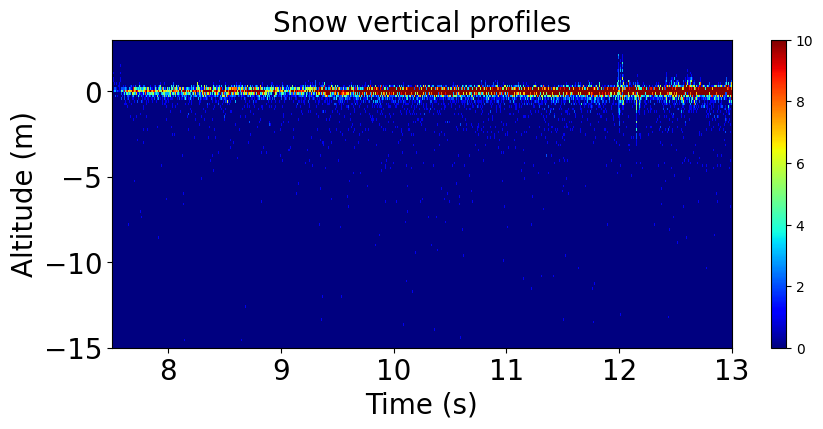

In [50]:

row1 = len(binx1)
# plt.figure()
plt.figure(figsize=(10, 4))  
# MATLAB: 1:1e2:row1  → Python slicing step = 100
x = binx1[:row1:1]
z = b_3[:row1:1, :].T   # transpose like MATLAB '
# z = np.real(np.log10(b_2_mean[:row1:100, :].T))

X, Y = np.meshgrid(x, y_alt1)

pcm = plt.pcolormesh(X, Y, z, cmap='jet', shading='auto')

plt.title('Snow vertical profiles', fontsize=20)
plt.xlabel('Time (s)', fontsize=20)
plt.ylabel('Altitude (m)', fontsize=20)

# plt.ylim([-15, 10])
plt.ylim(-15, 3) 
plt.xlim(7.5, 13)  
plt.clim(0, 10)

plt.tick_params(labelsize=20)

plt.colorbar(pcm)

# plt.xlim(50, 100)   # set x-axis range
plt.ylim(-15, 3) 

plt.show()

## Normalized Snow profiles
### Snow profiles normalized by the surface peak photon counts to reduce atmospheric effects.

## 

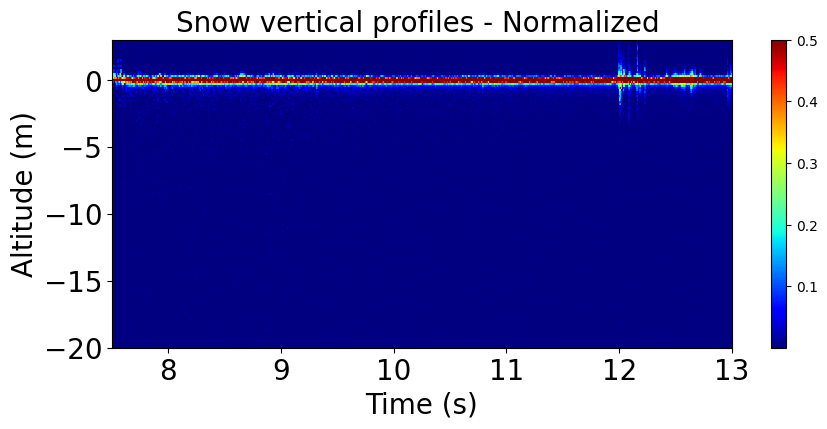

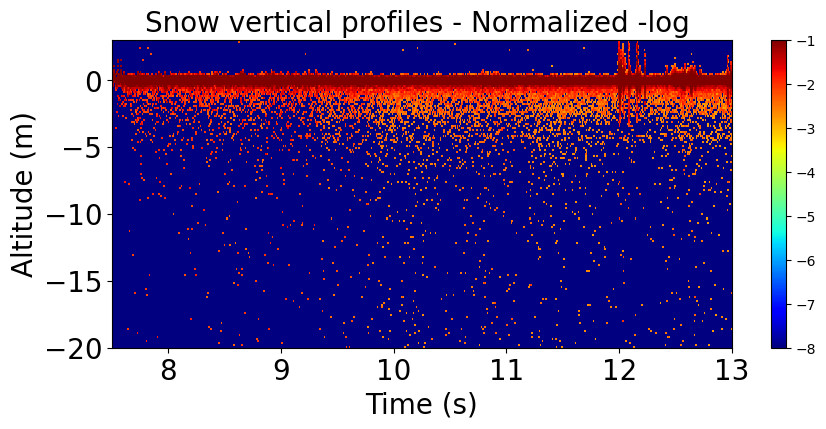

In [58]:
# plt.figure()
plt.figure(figsize=(10, 4)) 
# MATLAB: 1:1e2:row1  → Python slicing step = 100
x = binx1[:row1:1]
# z = np.real(np.log10(b_2_mean[:row1:1, :].T))
# z = np.log10(np.maximum(b_2_mean[:row1:1, :].T, 1e-10))
z = b_2_mean[:row1:1, :].T


X, Y = np.meshgrid(x, y_alt1)

pcm = plt.pcolormesh(X, Y, z, cmap='jet', shading='auto')

plt.title('Snow vertical profiles - Normalized ', fontsize=20)
# plt.xlabel('Profiles', fontsize=20)
plt.ylabel('Altitude (m)', fontsize=20)
plt.xlabel('Time (s)', fontsize=20)
plt.ylim(-15, 3) 
plt.xlim(7.5, 13)   # set x-axis range
plt.clim(1e-5, 0.5)

plt.tick_params(labelsize=20)

plt.colorbar(pcm)

# plt.xlim(50, 100)   # set x-axis range
plt.ylim(-20, 3) 

plt.show()




plt.figure(figsize=(10, 4)) 
# MATLAB: 1:1e2:row1  → Python slicing step = 100
x = binx1[:row1:1]
# z = np.real(np.log10(b_2_mean[:row1:1, :].T))
z = np.log10(np.maximum(b_2_mean[:row1:1, :].T, 1e-10))
# z = b_2_mean[:row1:1, :].T


X, Y = np.meshgrid(x, y_alt1)

pcm = plt.pcolormesh(X, Y, z, cmap='jet', shading='auto')

plt.title('Snow vertical profiles - Normalized -log ', fontsize=20)
# plt.xlabel('Profiles', fontsize=20)
plt.ylabel('Altitude (m)', fontsize=20)
plt.xlabel('Time (s)', fontsize=20)
plt.ylim(-15, 3) 
plt.xlim(7.5, 13)   # set x-axis range
plt.clim(-8, -1)

plt.tick_params(labelsize=20)

plt.colorbar(pcm)

# plt.xlim(50, 100)   # set x-axis range
plt.ylim(-20, 3) 

plt.show()

# Step 3 Get Snow Pathlength Distributions

In [12]:
# -----------------------------
# minus background
# -----------------------------
# here the background is assumed to be 1e-5
# You can read the background from ATL03 data
sub_sig = b_2_mean.T - 1e-5
sub_alt = y_alt1.copy()

# flip like MATLAB flipud
sub_sig = np.flipud(sub_sig)
sub_alt = np.flipud(sub_alt)

# -------------------------------------------------
# select depth range
# -------------------------------------------------
indsub = np.where((sub_alt <= 3) & (sub_alt >= depth_max))[0]

sub_alt2 = sub_alt[indsub]
sub_true4 = sub_sig[indsub, :].copy()

# remove negative values
sub_true4[sub_true4 < 0] = np.nan

# -------------------------------------------------
# parameter: snow absorption at 532nm
# -------------------------------------------------
# you can use other methods to find the appropriate absorption values for different cases
a = 0.05

# -------------------------------------------------
# exponential weighting, get the snow photon pathlength remove the absoprtion effect
# -------------------------------------------------
weight = np.exp(-2 * np.abs(sub_alt2)[:, None] * a)
weight_sub = sub_true4 / weight

# here weight_sub is the pathlength distribution

# Final step: Snow Depth Retrievals

$$
\Large
\text{Second-order moment of the snow multiple-scattering photon path distribution}
$$

$$
\LARGE
\text{Snow depth} = \left( \frac{4 \int z^2\, p(z)\, dz}{k_{sd} \int p(z)\, dz} \right)^{\frac{1}{3}}
$$

## References

Hu, Y., et al. (2022). *Deriving Snow Depth From ICESat-2 Lidar Multiple Scattering Measurements*. **Frontiers in Remote Sensing**, 3. https://doi.org/10.3389/frsen.2022.855159



In [27]:

# -------------------------------------------------
# safe denominator
# -------------------------------------------------
den = np.nansum(weight_sub, axis=0)

def safe_div(num, den):
    out = np.full_like(num, np.nan, dtype=float)
    valid = den != 0
    out[valid] = num[valid] / den[valid]
    return out

# -------------------------------------------------
# -------------------------------------------------
weight_1 = weight_sub * (-sub_alt2[:, None])
# -------------------------------------------------
# albedo
# -------------------------------------------------
A1 = safe_div(np.nansum(sub_true4, axis=0), den)

# -------------------------------------------------
# grain size + optical parameters
# -------------------------------------------------
R1 = ((1 - A1) / 8.43) ** 2 / a
R1 = np.where((R1 > 0) & np.isfinite(R1), R1, np.nan)
kd1 = 0.65 * np.sqrt(a / R1)
kx = kd1**2 / (3 * a)

# -------------------------------------------------
# 2nd moment snow depth
# -------------------------------------------------
H = -sub_alt2
H2 = weight_sub * (H[:, None] ** 2)
var2 = safe_div(np.nansum(H2, axis=0), den)
snow_depth2 = np.full_like(var2, np.nan, dtype=float)
valid2 = np.isfinite(var2) & (var2 > 0) & np.isfinite(kx) & (kx > 0)
snow_depth2[valid2] = (var2[valid2] * 4 / kx[valid2]) ** (1/3)

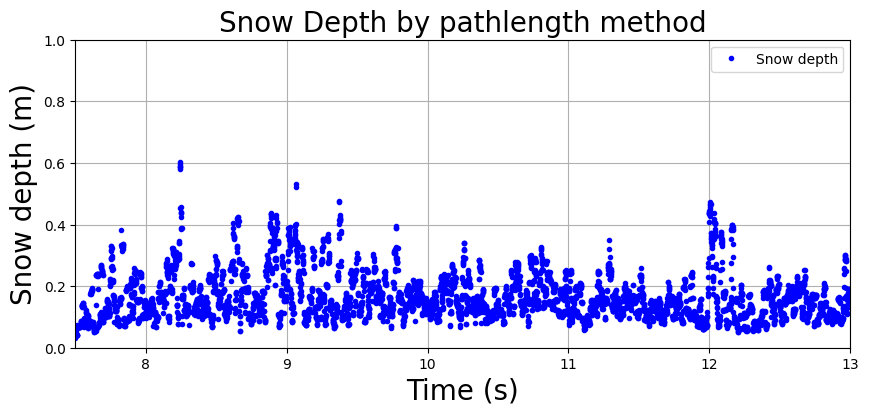

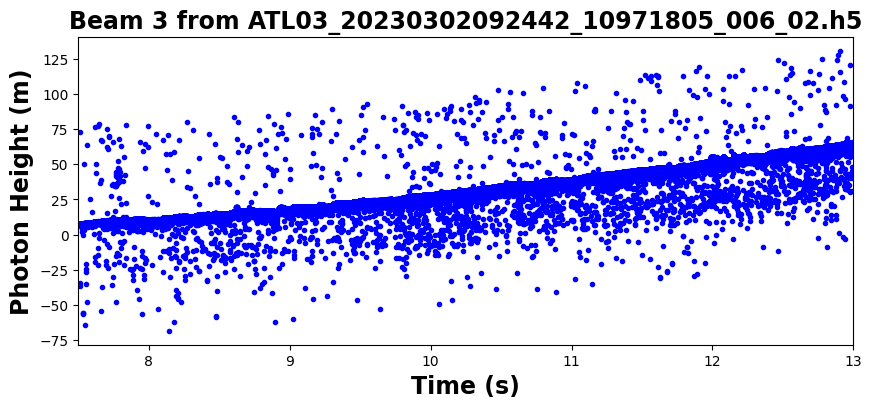

In [66]:

plt.figure(figsize=(10, 4)) 
plt.plot(binx1, snow_depth2, '.b', label='Snow depth')
plt.xlim(7.516, 12.261)
plt.ylim(0, 1)
plt.xlim(7.5, 13)   # set x-axis range
plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Snow depth (m)", fontsize=20)
plt.title("Snow Depth by pathlength method", fontsize=20)

plt.legend()
plt.grid(True)

plt.show()

# plt.figure()
h_ph1 = h_1r[:, 3]

plt.figure(figsize=(10, 4))  

# plt.subplot(2, 1, 1)
# plt.plot(h_lat, h_ph, '.b')   # 
plt.plot(h_t, h_ph1, '.b')   # 
plt.xlim(7.5, 13)   # set x-axis range
# plt.ylim(-50, 20)  

plt.xlabel('Time (s)', fontsize=17, fontweight='bold')
plt.ylabel('Photon Height (m)', fontsize=17, fontweight='bold')
plt.title('Beam 3 from ATL03_20230302092442_10971805_006_02.h5', fontsize=17, fontweight='bold')
plt.show()

# References

## Snow depth pathlength method References

Hu, Y., et al. (2022). *Deriving Snow Depth From ICESat-2 Lidar Multiple Scattering Measurements*. **Frontiers in Remote Sensing**, 3. https://doi.org/10.3389/frsen.2022.855159



Hu, Y.; et al., (2023) Linking Lidar Multiple Scattering Profiles to Snow Depth and Snow Density: An Analytical Radiative Transfer Analysis and the Implications for Remote Sensing of Snow. **Frontiers in Remote Sensing**. 4, doi:10.3389/frsen.2023.1202234,  https://doi.org/10.3389/frsen.2023.1202234

Lu, X.; et al., (2022). Deriving Snow Depth From ICESat-2 Lidar Multiple Scattering Measurements: Uncertainty Analyses. **Frontiers in Remote Sensing**. 2022, 3, doi:10.3389/frsen.2022.891481.https://www.frontiersin.org/journals/remote-sensing/articles/10.3389/frsen.2022.891481/full  

Lu, X., et al., (2026). ICESat-2 and SnowEx Surface Elevation Measurements: A Cross-Validation Study for Snow Depth Application. **Remote Sens.** 18. https://doi.org/10.3390/rs18020359 

## ICESat-2 impulse response and deconvolution method references
Lu, et al. (2021), “Enabling value added scientific applications of ICESat-2 data with effective removal of afterpulses', **Earth and Space Science** https://doi.org/10.1029/2021EA001729

Kurtz, N., Martino, A. J. & Pingel, A. (2026). ATLAS/ICESat-2 ATL02 Linear Impulse Response. (ATL02_ANC_LIR, Version 1). Boulder, Colorado USA. **NASA National Snow and Ice Data Center Distributed Active Archive Center**. https://doi.org/10.5067/EVKXYHW95FPJ.

Lu, X., et al. (2020). *New attenuated backscatter profile by removing the CALIOP receiver's transient response*. **Journal of Quantitative Spectroscopy and Radiative Transfer**, 255, 107244. https://doi.org/10.1016/j.jqsrt.2020.107244

